<a href="https://colab.research.google.com/github/raghavrakesh20/Small-projects-practice./blob/main/Materiality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

To analyze the materiality of your printed books, you can use the LAB color space in Python. This is more effective than standard RGB because it separates Lightness (L)—useful for tracking ink fading—from color information, specifically the b-channel, which tracks the yellow-to-blue spectrum where foxing (brown/rust spotting) occurs.

*Python Code for Material Analysis*
This script calculates histograms to quantify ink density and identifies potential foxing spots by isolating yellow-brown pixels.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def analyze_book_materiality(image_path):
    # 1. Load image and convert for analysis
    img = cv2.imread(image_path)
    if img is None: return "Image not found."
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # 2. Convert to LAB color space
    # L = Lightness, b = Blue-Yellow (positive values = yellow/brown)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # 3. Calculate Histograms using OpenCV
    hist_l = cv2.calcHist([l_channel], [0], None, [256], [0, 256])
    hist_b = cv2.calcHist([b_channel], [0], None, [256], [0, 256])

    # 4. Create a Foxing Heatmap (Isolate high b-channel values)
    # Thresholding helps isolate spots darker than paper but yellower than ink
    _, foxing_mask = cv2.threshold(b_channel, 150, 255, cv2.THRESH_BINARY)

    # 5. Visualization using Matplotlib
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))

    axs[0].imshow(img_rgb)
    axs[0].set_title("Original Page")
    axs[1].plot(hist_l, color='black', label='Ink/Paper Lightness')
    axs[1].plot(hist_b, color='gold', label='Yellowing (Foxing)')
    axs[1].set_title("Intensity Distribution")
    axs[1].legend()
    axs[2].imshow(foxing_mask, cmap='hot')
    axs[2].set_title("Foxing Heatmap")

    plt.show()

    # Quantitative Metrics
    print(f"Ink Contrast (L-StdDev): {np.std(l_channel):.2f}") # Higher = Sharper text
    print(f"Yellowing Index (Mean b): {np.mean(b_channel):.2f}") # Higher = More degradation



--- Analyzing: IMG_1688.JPG ---


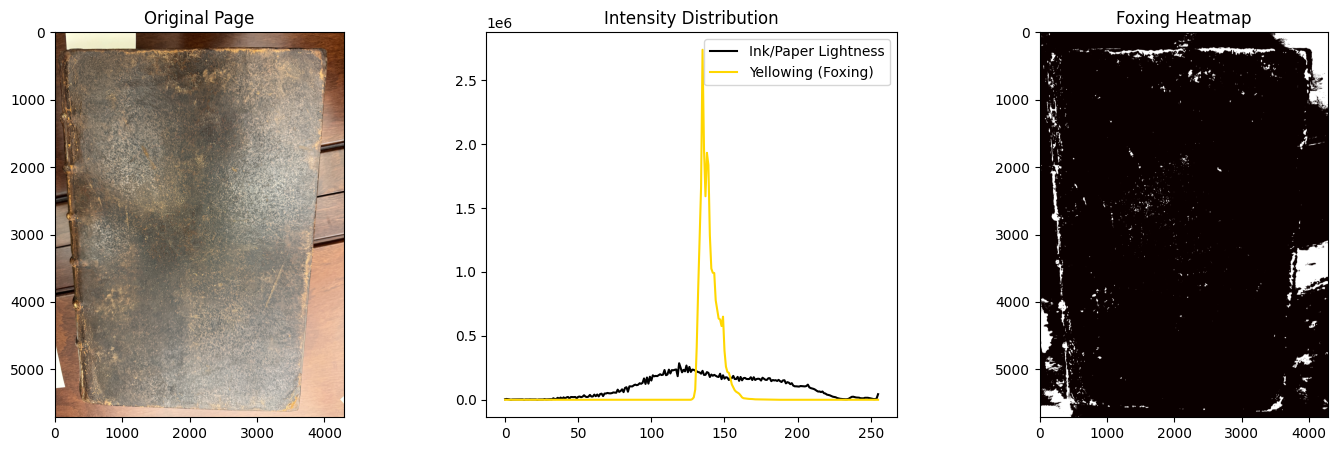

Ink Contrast (L-StdDev): 42.52
Yellowing Index (Mean b): 139.77

--- Analyzing: IMG_1689.JPG ---


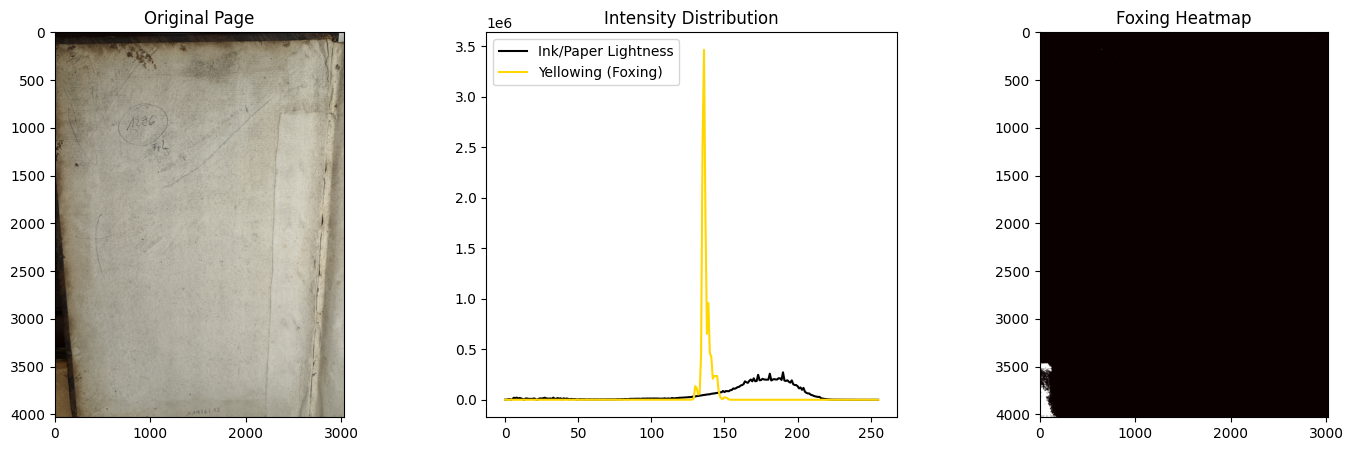

Ink Contrast (L-StdDev): 39.40
Yellowing Index (Mean b): 137.15

--- Analyzing: IMG_1690.JPG ---


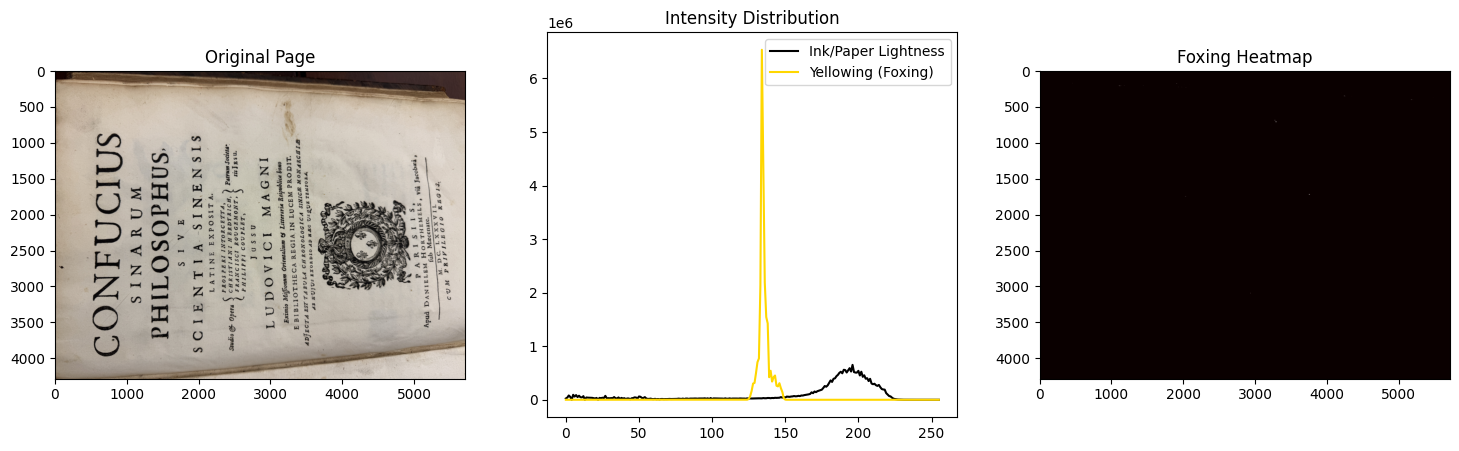

Ink Contrast (L-StdDev): 53.27
Yellowing Index (Mean b): 135.46


In [4]:
import os

# The actual files found in the directory were IMG_1688.JPG, IMG_1689.JPG, and IMG_1690.JPG
image_files = ['IMG_1688.JPG', 'IMG_1689.JPG', 'IMG_1690.JPG']

# Run analysis on these specific files
for img_name in image_files:
    if os.path.exists(img_name):
        print(f'\n--- Analyzing: {img_name} ---')
        analyze_book_materiality(img_name)
    else:
        print(f'File {img_name} not found. Please ensure it is uploaded.')